In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math
import scipy

In [2]:
xpoints = np.arange(0, 5, 0.01)

lam = 1.2

points_true = lam ** xpoints * np.exp(-lam) / scipy.special.factorial(xpoints) * xpoints

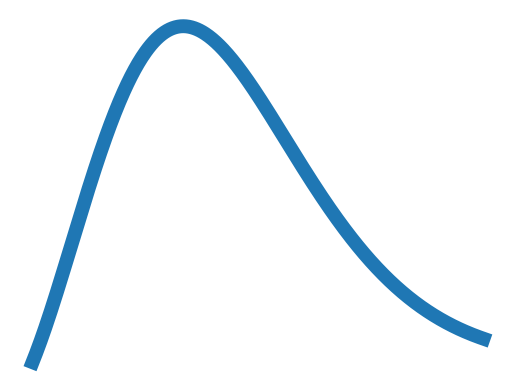

In [ ]:
plt.plot(xpoints, points_true, linewidth="10")
plt.axis("off")
plt.savefig("spectral_smooth.png", dpi=300)

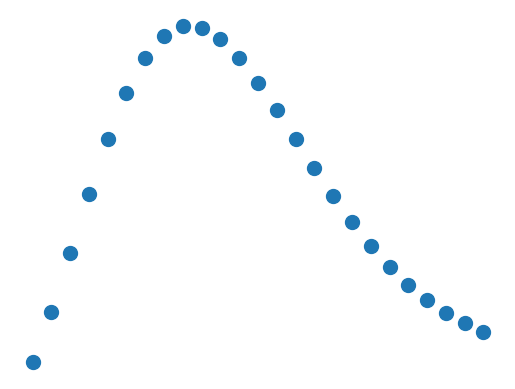

In [ ]:
plt.scatter(xpoints[::20], points_true[::20], s=100)
plt.axis("off")
plt.savefig("spectral_points.png", dpi=300)

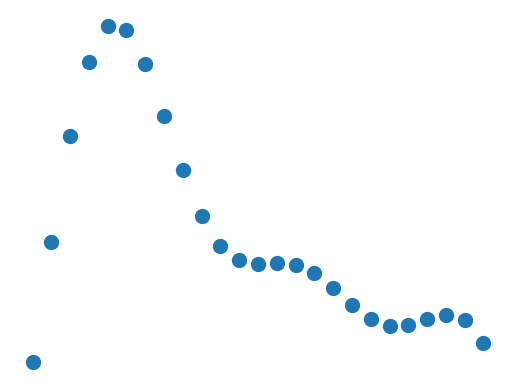

In [ ]:
frqs = [1, 2, 3]
amps = [0.3, 0.4, 0.2]

ab_initio = points_true.copy()

for (frq, amp) in zip(frqs, amps):
    ab_initio += amp * np.sin(2 * math.pi * frq * xpoints * 0.15)

plt.scatter(xpoints[::20], ab_initio[::20], s=100)
plt.axis("off")
plt.savefig("ab_initio_points.png", dpi=300)

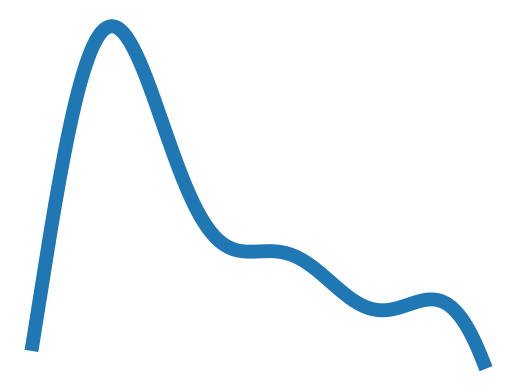

In [ ]:
plt.plot(xpoints, ab_initio, linewidth="10")
plt.axis("off")
plt.savefig("ab_initio_smooth.png", dpi=300)

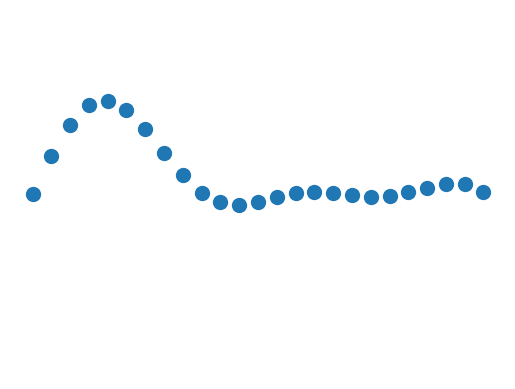

In [ ]:
residual = ab_initio - points_true

plt.scatter(xpoints[::20], residual[::20], s=100)
plt.ylim(-1.5, 1.5)
plt.axis("off")

plt.savefig("residual_points.png", dpi=300)

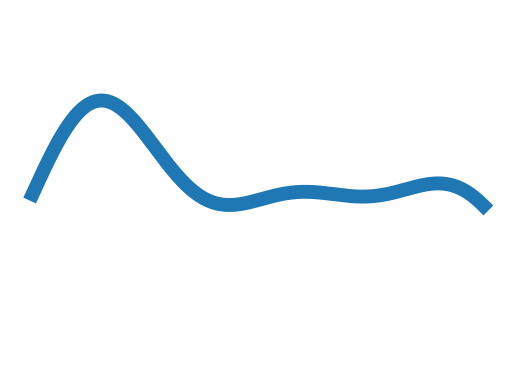

In [ ]:
plt.plot(xpoints, residual, linewidth = 10)
plt.axis("off")
plt.ylim(-1.5, 1.5)
plt.savefig("residual_smooth.png", dpi=300)

In [21]:
step = 50
sub_x = xpoints[::step]
sub_y = points_true[::step]

interp = scipy.interpolate.interp1d(sub_x, sub_y, kind="cubic")(xpoints[:-step])

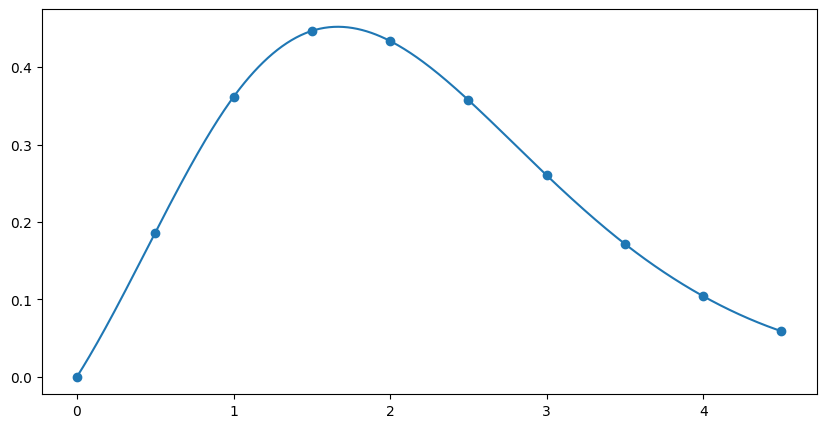

In [22]:
plt.figure(figsize=(10, 5))
plt.scatter(sub_x, sub_y)
plt.plot(xpoints[:-step], interp)

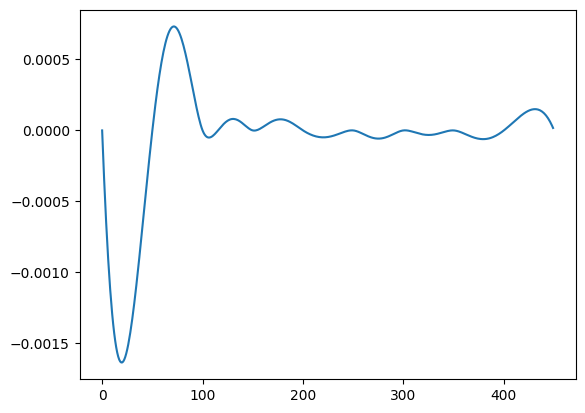

In [24]:
errors = points_true[:-step] - interp
plt.plot(errors)